In [22]:
#Importing the Libraries required for this project
#1. pandas: it will be used for data manipulation
import pandas as pd
#2. numpy: it is used for numerical operations and array handling
import numpy as np 
#3. matplotlib: used for creating basic plots and charts that will help to visualize the dataset
import matplotlib.pyplot as plt
#4. seaborn: built on top of matplotlib, creates better looking statistical plots
import seaborn as sns


In [ ]:

# loading the dataset
# pd.read_csv() reads our CSV file and converts it into a DataFrame

#df stands for dataframe which is 2 dimensional data structure in pandas.it stores tabular data in rows and columns.dataframe
df = pd.read_csv('C:\\Users\\Ar\\Desktop\\stroke_prediction\\data\\heart.csv')


In [24]:
# checking the dataset 
# to check the first 5 rows of dataset
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [25]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [26]:
# now we will check the basic statistics like mean, median, mode, standard deviation, minimum and maximum values of the dataset
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [27]:
# checking missing values in dataset
# isnull() marks every missing value as True
# sum() counts how many True values per column
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [28]:
# checking the class balance
#value_counts() counts how many 0s and 1s in HeartDisease column
# 0 = No heart disease
# 1 = Has heart disease

print(df['HeartDisease'].value_counts())

HeartDisease
1    508
0    410
Name: count, dtype: int64


In [29]:
# in percentage
print(df['HeartDisease'].value_counts(normalize=True) * 100)

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


C:\Users\Ar\AppData\Local\Temp\ipykernel_8260\3945146560.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df,
c:\Users\Ar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Ar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


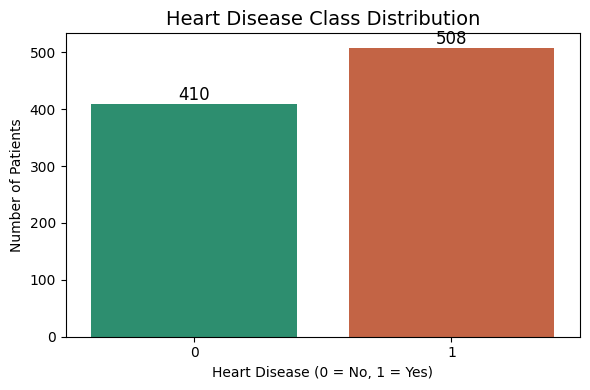

In [30]:
# visualizing class balance 
# We create a count plot to visually see the balance
# between patients with and without heart disease
plt.figure(figsize=(6, 4))
# here countplot creates a bar chart shows the no. of patient with or without heart disease
sns.countplot(x='HeartDisease', data=df, 
              palette=['#1D9E75', '#D85A30'])

# Adding labels to make chart readable
plt.title('Heart Disease Class Distribution', fontsize=14)
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')


# Adding exact numbers on top of each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

c:\Users\Ar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Ar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Ar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(

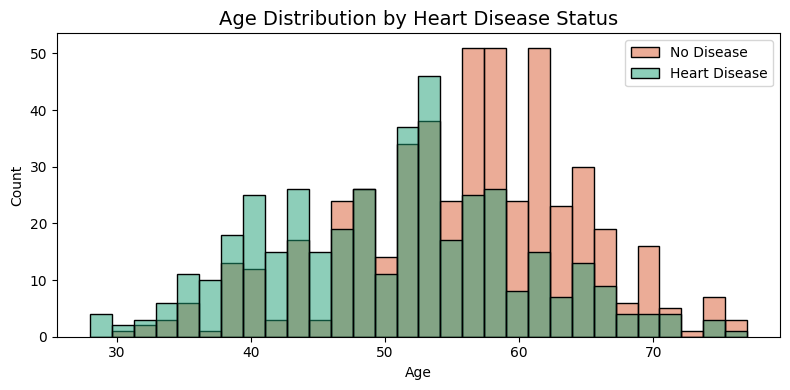

In [31]:
# visualizing the distribution of age in the dataset
plt.figure(figsize=(8, 4))

# Plot age distribution separately for disease vs no disease
# This helps us see if age is a strong predictor
sns.histplot(data=df, x='Age', hue='HeartDisease', 
             bins=30, palette=['#1D9E75', '#D85A30'])

plt.title('Age Distribution by Heart Disease Status', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(labels=['No Disease', 'Heart Disease'])
plt.tight_layout()
plt.show()




In [32]:
# checking if there is any missing values in the dataset
chol_zeros = (df['Cholesterol'] == 0).sum()
bp_zeros = (df['RestingBP'] == 0).sum()

print(f"Patients with Cholesterol = 0: {chol_zeros}")
print(f"Patients with RestingBP = 0: {bp_zeros}")
print(f"\nThese are hidden missing values!")
print(f"We will replace them with median values in preprocessing")


Patients with Cholesterol = 0: 172
Patients with RestingBP = 0: 1

These are hidden missing values!
We will replace them with median values in preprocessing


In [33]:

# median value of cholesterol and resting blood pressure
print("Current Cholesterol median:", df['Cholesterol'].median())
print("Current RestingBP median:", df['RestingBP'].median())

Current Cholesterol median: 223.0
Current RestingBP median: 130.0


In [34]:

# Replace RestingBP zeros with median
bp_median = df[df['RestingBP'] != 0]['RestingBP'].median()
df['RestingBP'] = df['RestingBP'].replace(0, bp_median)
print("RestingBP zeros remaining:", (df['RestingBP'] == 0).sum())

RestingBP zeros remaining: 0


In [35]:
# Replace Cholesterol zeros with median
chol_median = df[df['Cholesterol'] != 0]['Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, chol_median)
print("Cholesterol zeros remaining:", (df['Cholesterol'] == 0).sum())


Cholesterol zeros remaining: 0


In [36]:
# now encoding the categorical variables into numerical values 
# We use pd.get_dummies() which creates new columns for each category
# This is called One Hot Encoding
# drop_first=True removes one column from each group
# to avoid multicollinearity (duplicate information)
df_encoded = pd.get_dummies(df, columns=['Sex', 
                                          'ChestPainType',
                                          'RestingECG', 
                                          'ExerciseAngina', 
                                          'ST_Slope'], 
                             drop_first=True)

print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)
print("New columns:", list(df_encoded.columns))


Shape before encoding: (918, 12)
Shape after encoding: (918, 16)
New columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [37]:
# now , we will split the dataset into features and target variable
# Features are the input variables (X) that we will use to predict the target
# drop() removes HeartDisease from features
# We don't want the answer inside the input!
X = df_encoded.drop('HeartDisease', axis=1)

# y contains only the target column
y = df_encoded['HeartDisease']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", list(X.columns))
print("Target unique values:", y.unique())



X shape: (918, 15)
y shape: (918,)
Features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']
Target unique values: [0 1]


# Splitting the dataset
### We split data into 80% training and 20% testing
### 80% → model learns from this
### 20% → we test how well model performs on unseen data

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=0.2, 
                                                      random_state=42,
                                                      stratify=y)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Split done ✓")

X_train shape: (734, 15)
y_train shape: (734,)
Split done ✓


In [42]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Step 1: Scale the data first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling done ✓")

# Step 2: Apply SMOTE after scaling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print("Training set shape:", X_train_scaled.shape)
print(y_train.value_counts())

print("After SMOTE:")
print("Training set shape:", X_train_smote.shape)
print(y_train_smote.value_counts())

Scaling done ✓
Before SMOTE:
Training set shape: (734, 15)
HeartDisease
1    406
0    328
Name: count, dtype: int64
After SMOTE:
Training set shape: (812, 15)
HeartDisease
1    406
0    406
Name: count, dtype: int64


## Feature Scaling

- StandardScaler converts all numeric values to the same scale
- Without scaling, model thinks higher numbers are more important
- Example: Age = 54 vs Cholesterol = 223 → model favors Cholesterol unfairly
- After scaling, all values become small numbers around 0
- Model then treats all features equally and fairly

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform on training data only
# transform on test data only
# never fit on test data — that would be cheating!
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Scaling complete ✓")
print("Sample scaled values:", X_train_scaled[0])

X_train_scaled shape: (734, 15)
X_test_scaled shape: (184, 15)
Scaling complete ✓
Sample scaled values: [ 0.9700116   0.3390158  -0.51402763  1.83549656 -0.32451998  0.31704567
  0.51740017  2.0969165  -0.51740017 -0.24007684 -1.24799491  2.05077394
  1.20277457  0.98110491 -0.86224587]


## SMOTE — Synthetic Minority Oversampling Technique

- Our dataset has 406 disease vs 328 no disease in training set
- Difference is not huge but SMOTE makes it perfectly balanced
- SMOTE creates NEW synthetic patients for the minority class
- It does NOT just copy existing patients
- It interpolates between existing minority samples to create new ones
- Rule:  we apply SMOTE on training data ONLY


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
# random_state=42 ensures same results every time
smote = SMOTE(random_state=42)

In [ ]:
# fit_resample creates synthetic samples
# only applied on training data!
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, 
                                                    y_train)

print("Before SMOTE:")
print("Training set shape:", X_train_scaled.shape)
print(y_train.value_counts())

print("After SMOTE:")
print("Training set shape:", X_train_smote.shape)
print(y_train_smote.value_counts())



Before SMOTE:
Training set shape: (734, 15)
HeartDisease
1    406
0    328
Name: count, dtype: int64
After SMOTE:
Training set shape: (812, 15)
HeartDisease
1    406
0    406
Name: count, dtype: int64


In [ ]:

print("X_train_smote shape:", X_train_smote.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_train_smote shape:", y_train_smote.shape)
print("y_test shape:", y_test.shape)
print("Ready to train model ✓")

X_train_smote shape: (812, 15)
X_test_scaled shape: (184, 15)
y_train_smote shape: (812,)
y_test shape: (184,)
Ready to train model ✓


## Linear Regression Model

- Logistic Regression predicts probability between 0 and 1
- If probability >= 0.5 → patient has heart disease (1)
- If probability < 0.5 → patient has no heart disease (0)
- Uses sigmoid function to convert any number into 0-1 range
- Chosen because it is interpretable, fast and works well for binary classification

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
# Train the model on SMOTE balanced training data
# X_train_smote = features, y_train_smote = target
# model learns the relationship between features and heart disease
model.fit(X_train_smote, y_train_smote)

print("Model trained successfully ✓")
print("Number of iterations:", model.n_iter_)

NameError: name 'X_train_smote' is not defined

## Making predictions


In [ ]:
# NEW
# Linear Regression outputs continuous values like 0.3, 0.7, 1.2
# We apply threshold of 0.5 to convert to binary 0 or 1
y_pred_raw = model.predict(X_test_scaled)

# Convert continuous output to binary using threshold
y_pred = (y_pred_raw >= 0.5).astype(int)

# Use raw predictions as probability equivalent for ROC curve
y_pred_proba = y_pred_raw

print("Predictions made ✓")
print("First 10 raw predictions:", y_pred_raw[:10].round(2))
print("First 10 binary predictions:", y_pred[:10])
print("Actual values:            ", y_test.values[:10])

In [ ]:
# Coefficients tell us how important each feature is
# Positive coefficient → feature increases heart disease risk
# Negative coefficient → feature decreases heart disease risk
# Larger absolute value → stronger impact on prediction

import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0].round(3)
})

# Sort by absolute value to see most important features first
coefficients = coefficients.reindex(
    coefficients['Coefficient'].abs().sort_values(ascending=False).index
)

print("Feature Coefficients:")
print(coefficients)

Feature Coefficients:
              Feature  Coefficient
14        ST_Slope_Up       -0.755
8   ChestPainType_NAP       -0.723
7   ChestPainType_ATA       -0.623
6               Sex_M        0.601
12   ExerciseAngina_Y        0.455
3           FastingBS        0.440
13      ST_Slope_Flat        0.413
4               MaxHR       -0.317
9    ChestPainType_TA       -0.307
5             Oldpeak        0.215
0                 Age        0.115
10  RestingECG_Normal       -0.021
11      RestingECG_ST        0.020
1           RestingBP       -0.019
2         Cholesterol        0.016


In [ ]:

import joblib

# Full path ensures files save in correct project folder
base_path = r'C:\Users\Ar\Desktop\stroke_prediction'

joblib.dump(model, base_path + r'\model.pkl')
joblib.dump(scaler, base_path + r'\scaler.pkl')

print("Model saved ✓")
print("Scaler saved ✓")
print("Saved in:", base_path)

Model saved ✓
Scaler saved ✓
Saved in: C:\Users\Ar\Desktop\stroke_prediction


## Model Evaluation

- Accuracy alone can be misleading in healthcare
- We need to know: how many actual disease cases did we correctly catch?
- Confusion Matrix shows 4 outcomes: TP, TN, FP, FN
- FN (False Negative) is the most dangerous — missing a real disease case
- Recall measures how well we catch real disease cases
- Precision measures how many predicted cases were actually correct

In [ ]:
from sklearn.metrics import confusion_matrix
# Confusion matrix compares actual vs predicted values
# Format:
# [[TN, FP],
#  [FN, TP]]
# TN = correctly predicted no disease
# FP = predicted disease but actually no disease (false alarm)
# FN = predicted no disease but actually has disease (DANGEROUS!)
# TP = correctly predicted disease

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[72 10]
 [14 88]]


In [ ]:
# Extract individual values for clarity
tn, fp, fn, tp = cm.ravel()
print("\nTrue Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn, "← DANGEROUS! Missed disease cases")
print("True Positive (TP):", tp)


True Negative (TN): 72
False Positive (FP): 10
False Negative (FN): 14 ← DANGEROUS! Missed disease cases
True Positive (TP): 88


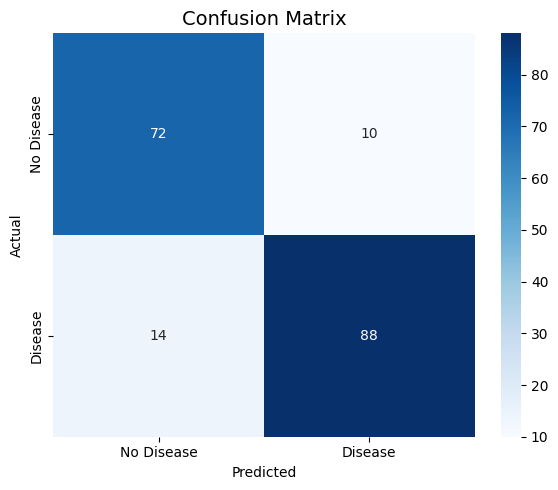

In [ ]:
# visulaizing the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])

plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# calculating evaluation matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [ ]:
# Accuracy = how many predictions were correct overall
accuracy = accuracy_score(y_test, y_pred)

# Precision = of all predicted "disease" cases, how many were correct
precision = precision_score(y_test, y_pred)

# Recall = of all actual "disease" cases, how many did we catch
# MOST IMPORTANT METRIC for healthcare
recall = recall_score(y_test, y_pred)

# F1 = balance between precision and recall
f1 = f1_score(y_test, y_pred)

print("Accuracy: ", round(accuracy*100, 2), "%")
print("Precision:", round(precision*100, 2), "%")
print("Recall:   ", round(recall*100, 2), "%")
print("F1 Score: ", round(f1*100, 2), "%")

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy:  86.96 %
Precision: 89.8 %
Recall:    86.27 %
F1 Score:  88.0 %

Full Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        82
           1       0.90      0.86      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
# ROC curve shows tradeoff between True Positive Rate 
# and False Positive Rate at different thresholds
# AUC = Area Under Curve, ranges 0 to 1
# AUC closer to 1 = better model
# AUC of 0.5 = model is just guessing randomly

AUC Score: 0.932


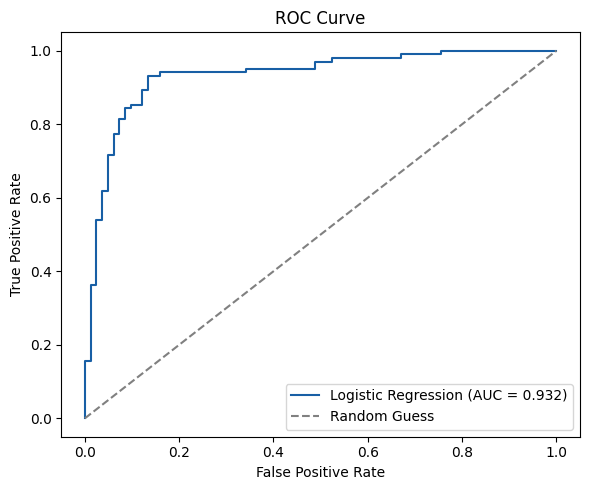

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

print("AUC Score:", round(auc_score, 3))

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})', color='#185FA5')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()